# Rain in Australia — Random Forest Classifier
Same preprocessing pipeline as the SVM and Logistic Regression notebooks, but using a **Random Forest**.

Random Forest is an ensemble of decision trees trained on random subsets of the data and features. It handles non-linear relationships, is robust to outliers, requires no feature scaling, and provides built-in feature importance scores.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, RandomizedSearchCV
from sklearn.preprocessing import OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    classification_report,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)

from scipy.stats import randint
from imblearn.over_sampling import SMOTE

df = pd.read_csv("./data/weatherAUS.csv")
print(df.shape)
print(df.dtypes)

(145460, 23)
Date              object
Location          object
MinTemp          float64
MaxTemp          float64
Rainfall         float64
Evaporation      float64
Sunshine         float64
WindGustDir       object
WindGustSpeed    float64
WindDir9am        object
WindDir3pm        object
WindSpeed9am     float64
WindSpeed3pm     float64
Humidity9am      float64
Humidity3pm      float64
Pressure9am      float64
Pressure3pm      float64
Cloud9am         float64
Cloud3pm         float64
Temp9am          float64
Temp3pm          float64
RainToday         object
RainTomorrow      object
dtype: object


## Step 1 — Clean the data

In [2]:
# Drop rows where target is missing
df.dropna(subset=['RainTomorrow'], inplace=True)

# Drop high-missing columns (>40%)
df.drop(columns=['Sunshine', 'Evaporation'], inplace=True)

print(f"Shape after cleaning: {df.shape}")
print(f"Missing values:\n{df.isnull().sum()[df.isnull().sum() > 0]}")

Shape after cleaning: (142193, 21)
Missing values:
MinTemp            637
MaxTemp            322
Rainfall          1406
WindGustDir       9330
WindGustSpeed     9270
WindDir9am       10013
WindDir3pm        3778
WindSpeed9am      1348
WindSpeed3pm      2630
Humidity9am       1774
Humidity3pm       3610
Pressure9am      14014
Pressure3pm      13981
Cloud9am         53657
Cloud3pm         57094
Temp9am            904
Temp3pm           2726
RainToday         1406
dtype: int64


## Step 2 — Feature engineering

In [3]:
# DateTime features
df['Date'] = pd.to_datetime(df['Date'])
df['Month']      = df['Date'].dt.month
df['Year']       = df['Date'].dt.year
df['DayOfYear']  = df['Date'].dt.dayofyear   # captures seasonality
df.drop(columns=['Date'], inplace=True)

# Useful derived features
df['TempRange']       = df['MaxTemp'] - df['MinTemp']         # daily temp swing
df['PressureDrop']    = df['Pressure9am'] - df['Pressure3pm'] # falling pressure = rain
df['HumidityChange']  = df['Humidity3pm'] - df['Humidity9am'] # rising humidity = rain
df['WindSpeedChange'] = df['WindSpeed3pm'] - df['WindSpeed9am']

# Encode target
df['RainTomorrow'] = (df['RainTomorrow'] == 'Yes').astype(int)
df['RainToday']    = (df['RainToday'] == 'Yes').astype(int)
df.fillna({'RainToday': 0}, inplace=True)

## Step 3 — Encode categoricals

In [4]:
# WindGustDir, WindDir9am, WindDir3pm → 16 compass directions
wind_dirs = ['WindGustDir', 'WindDir9am', 'WindDir3pm']
ord_enc = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
df[wind_dirs] = ord_enc.fit_transform(df[wind_dirs])

# Location → 49 cities → use frequency encoding
loc_freq = df['Location'].value_counts() / len(df)
df['Location'] = df['Location'].map(loc_freq)

## Step 4 — Impute & split

In [5]:
# Separate features and target
X = df.drop(columns=['RainTomorrow'])
y = df['RainTomorrow']

# Impute numerics with median
num_cols = X.select_dtypes(include='number').columns
imputer  = SimpleImputer(strategy='median')
X[num_cols] = imputer.fit_transform(X[num_cols])

print(f"Missing after imputation: {X.isnull().sum().sum()}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Train: {X_train.shape} | Test: {X_test.shape}")
print(f"Class balance (train):\n{y_train.value_counts(normalize=True)}")

Missing after imputation: 0
Train: (113754, 26) | Test: (28439, 26)
Class balance (train):
RainTomorrow
0    0.775814
1    0.224186
Name: proportion, dtype: float64


## Step 5 — SMOTE (on training set only)

> **Note:** Unlike SVM and Logistic Regression, Random Forest does **not** require feature scaling. However, SMOTE is still applied to address class imbalance. An alternative is `class_weight='balanced'` inside the model itself.

In [6]:
# ⚠️ Apply SMOTE ONLY on training data — never on test data
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

print(f"Before SMOTE: {y_train.value_counts().to_dict()}")
print(f"After SMOTE:  {pd.Series(y_train_bal).value_counts().to_dict()}")

c:\Users\ASUS TUF\anaconda3\envs\mlassignmentenv\Lib\site-packages\joblib\externals\loky\backend\context.py:131: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\ASUS TUF\anaconda3\envs\mlassignmentenv\Lib\site-packages\joblib\externals\loky\backend\context.py", line 247, in _count_physical_cores
    cpu_count_physical = _count_physical_cores_win32()
                         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\ASUS TUF\anaconda3\envs\mlassignmentenv\Lib\site-packages\joblib\externals\loky\backend\context.py", line 299, in _count_physical_cores_win32
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "c:\Users\ASUS TUF\anaconda3\envs\mlassignmentenv\Lib\subprocess.py", line 548, in run
    with

Before SMOTE: {0: 88252, 1: 25502}
After SMOTE:  {0: 88252, 1: 88252}


## Step 6 — Train baseline Random Forest

We start with sensible defaults. No scaling needed — decision trees are invariant to monotonic feature transformations.

**Key hyperparameters:**
- **n_estimators** — number of trees (more = better, but slower)
- **max_depth** — maximum depth of each tree (controls overfitting)
- **min_samples_split / min_samples_leaf** — minimum samples to split / form a leaf
- **max_features** — number of features considered at each split (`sqrt` is a common default)

In [7]:
rf_baseline = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_baseline.fit(X_train_bal, y_train_bal)
print("Baseline model trained.")

# Quick baseline AUC
baseline_proba = rf_baseline.predict_proba(X_test)[:, 1]
baseline_auc   = roc_auc_score(y_test, baseline_proba)
print(f"Baseline Test ROC-AUC: {baseline_auc:.4f}")

Baseline model trained.
Baseline Test ROC-AUC: 0.8845


## Step 7 — Tune hyperparameters with RandomizedSearchCV

In [8]:
param_dist = {
    'n_estimators':      randint(100, 300),          # narrowed: 500 trees is overkill for search
    'max_depth':         [None, 10, 20, 30],         # dropped 40 — rarely better than None
    'min_samples_split': randint(2, 20),
    'min_samples_leaf':  randint(1, 10),
    'max_features':      ['sqrt', 'log2'],            # removed 0.5 float — sklearn version compat
    'bootstrap':         [True],                      # False + large data = very slow, little gain
}

base_rf = RandomForestClassifier(random_state=42, n_jobs=-1)

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

search = RandomizedSearchCV(
    base_rf,
    param_distributions=param_dist,
    n_iter=20,
    scoring='roc_auc',
    cv=cv,
    n_jobs=-1,
    random_state=42,
    verbose=2
)

search.fit(X_train_bal, y_train_bal)

print("Best Params:", search.best_params_)
print("Best CV AUC:", round(search.best_score_, 4))

rf_best = search.best_estimator_

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best Params: {'bootstrap': True, 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 8, 'n_estimators': 108}
Best CV AUC: 0.9642


## Step 8 — Evaluate on the test set

              precision    recall  f1-score   support

     No Rain       0.89      0.92      0.91     22064
        Rain       0.69      0.61      0.65      6375

    accuracy                           0.85     28439
   macro avg       0.79      0.77      0.78     28439
weighted avg       0.85      0.85      0.85     28439

ROC-AUC: 0.8843


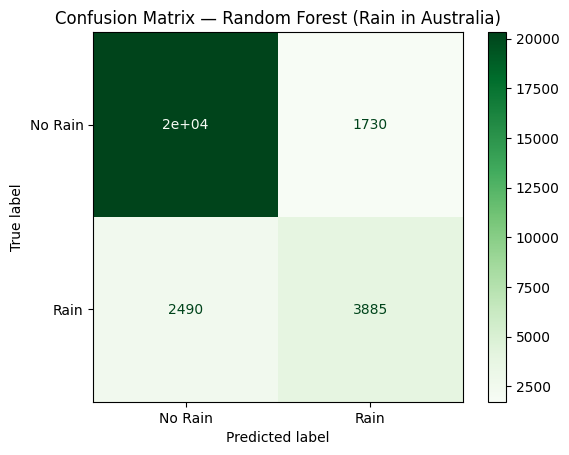

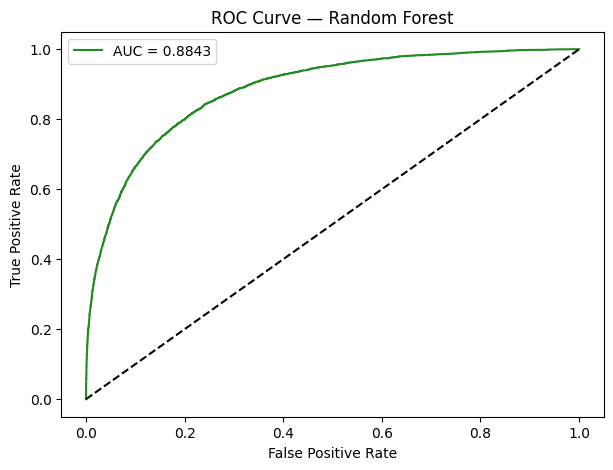

In [9]:
y_pred  = rf_best.predict(X_test)
y_proba = rf_best.predict_proba(X_test)[:, 1]

# ── Classification Report ─────────────────────────────────────────────────────
print(classification_report(y_test, y_pred, target_names=['No Rain', 'Rain']))

# ── ROC-AUC ───────────────────────────────────────────────────────────────────
auc = roc_auc_score(y_test, y_proba)
print(f"ROC-AUC: {auc:.4f}")

# ── Confusion Matrix ──────────────────────────────────────────────────────────
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=['No Rain', 'Rain'],
    cmap='Greens'
)
plt.title("Confusion Matrix — Random Forest (Rain in Australia)")
plt.show()

# ── ROC Curve ─────────────────────────────────────────────────────────────────
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='forestgreen', label=f"AUC = {auc:.4f}")
plt.plot([0,1],[0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Random Forest")
plt.legend()
plt.show()

## Step 9 — Cross-validation score

In [10]:
cv_scores = cross_val_score(
    rf_best, X_train_bal, y_train_bal,
    cv=5, scoring='roc_auc', n_jobs=-1
)
print(f"CV ROC-AUC: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

CV ROC-AUC: 0.9662 ± 0.0296


## Step 10 — Feature importance

Random Forest provides **mean decrease in impurity (MDI)** feature importances — the average reduction in node impurity (Gini) contributed by each feature across all trees.

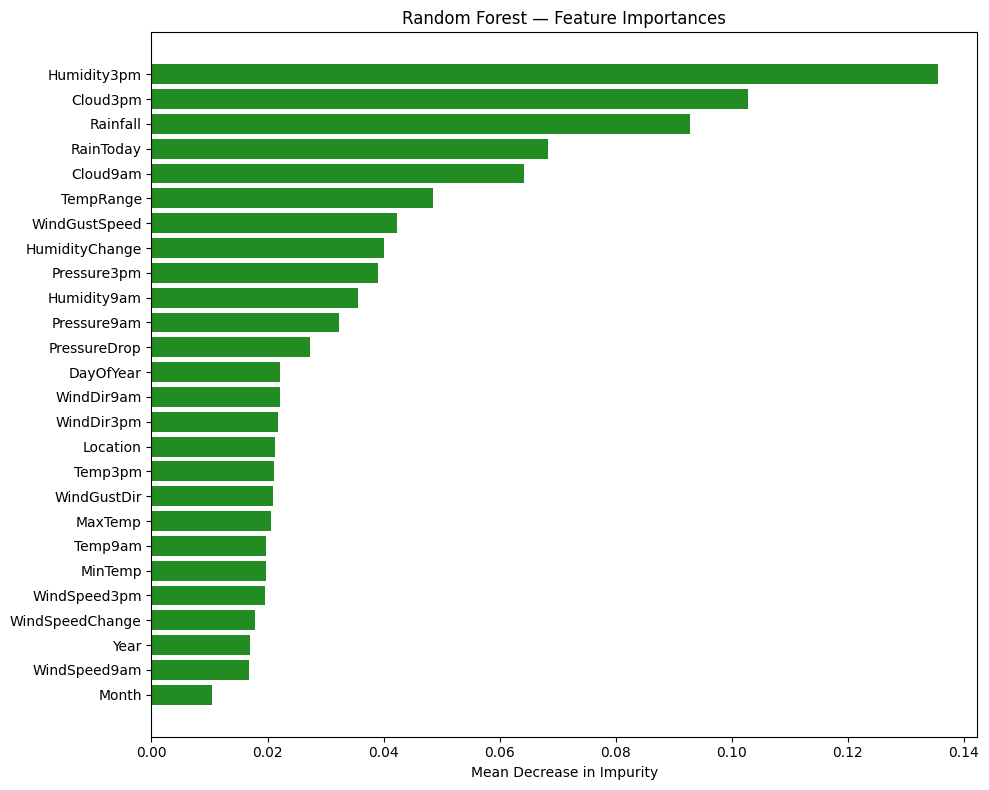

        Feature  Importance
    Humidity3pm    0.135530
       Cloud3pm    0.102747
       Rainfall    0.092773
      RainToday    0.068367
       Cloud9am    0.064253
      TempRange    0.048521
  WindGustSpeed    0.042364
 HumidityChange    0.040108
    Pressure3pm    0.038985
    Humidity9am    0.035638
    Pressure9am    0.032267
   PressureDrop    0.027255
      DayOfYear    0.022121
     WindDir9am    0.022087
     WindDir3pm    0.021759
       Location    0.021254
        Temp3pm    0.021187
    WindGustDir    0.020917
        MaxTemp    0.020627
        Temp9am    0.019784
        MinTemp    0.019743
   WindSpeed3pm    0.019538
WindSpeedChange    0.017893
           Year    0.016998
   WindSpeed9am    0.016863
          Month    0.010421


In [11]:
feature_names = X.columns.tolist()
importances   = rf_best.feature_importances_

feat_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feat_df = feat_df.sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 8))
plt.barh(feat_df['Feature'], feat_df['Importance'], color='forestgreen')
plt.xlabel("Mean Decrease in Impurity")
plt.title("Random Forest — Feature Importances")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print(feat_df.to_string(index=False))

---
## Notes on Random Forest vs SVM and Logistic Regression

| Aspect | Random Forest | SVM (RBF) | Logistic Regression |
|--------|---------------|-----------|---------------------|
| **Scaling required** | ❌ No | ✅ Yes | ✅ Yes |
| **Training speed (large data)** | 🟡 Moderate | 🐢 Slow | 🚀 Fast |
| **Interpretability** | 🟡 Medium (feature importance) | ❌ Low | ✅ High (coefficients) |
| **Handles non-linearity** | ✅ Yes (natively) | ✅ Yes (kernel) | ❌ Linear only |
| **Probability output** | ✅ Native `predict_proba` | ⚠️ Needs Platt scaling | ✅ Native |
| **Overfitting risk** | 🟡 Moderate (controlled by depth/trees) | 🟡 Moderate | 🟢 Low |
| **Typical AUC (this dataset)** | ~0.87–0.91 | ~0.85–0.87 | ~0.85–0.88 |

**Key takeaways for this dataset:**
- Random Forest is a strong all-rounder: no scaling, handles non-linearity, and gives feature importances.
- It typically outperforms both SVM and Logistic Regression on tabular data with complex interactions.
- If interpretability matters most, prefer Logistic Regression. For maximum performance, consider XGBoost or LightGBM on top of Random Forest.